## Fees Topic Overview Analysis

This notebook analyzes YouTube comments and videos discussing **college/university fees** across 100 Indian universities. It follows the same technique set used in the Placement analysis (cleaning, TF, TF-IDF, word cloud, engagement, sentiment, topic modeling, university-wise and trend analysis), and adds a **fees-specific layer**: extracting actual fee amounts people mention (lakhs/crores/₹) and categorizing comments by the type of fee concern they raise (scholarship, loan/EMI, affordability, hostel/mess, refund, comparison).

### TECHNIQUE 1: Data Cleaning & Preprocessing

#### Clean noisy text

##### Why this Technique was Used

Data preprocessing helps in:
Removing noisy and irrelevant information.
Improving text consistency.
Preparing data for frequency analysis, sentiment analysis, and topic modeling.
Reducing errors in downstream NLP tasks.

In [1]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import re
import os

# Every chart in this notebook is also saved as a standalone PNG here,
# in addition to rendering inline.
os.makedirs("figures", exist_ok=True)

# Set the plotting backend to inline explicitly (works even if this
# notebook is restarted, run cell-by-cell, or run out of order) so every
# plt.show() below actually renders a chart instead of doing nothing.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("png")
import matplotlib.pyplot as plt

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv(
    "india_universities_fees_comments.csv"
)

df.head()

,comment_id,thread_id,parent_comment_id,video_id,video_title,channel_name,university_name,category,keyword,author_name,...,comment_month,likes,reply_count,is_reply,comment_type,comment_length,word_count,contains_question,contains_url,contains_emoji
0,Ugz1rnWrI0RRGzoqImJ4AaABAg,Ugz1rnWrI0RRGzoqImJ4AaABAg,NaN,n9URGnN1ZvA,IIT Delhi M.Tech Fees 2025 | Total Cost of Doi...,Sonu Yadav [ IIT-Delhi ],IIT Delhi,fees,fees review,@sonuyadav5504.,...,4,8,1,False,parent,320,46,True,True,True
1,Ugz1rnWrI0RRGzoqImJ4AaABAg.AGSkvq2lsm0AKfhMH8uJNT,Ugz1rnWrI0RRGzoqImJ4AaABAg,Ugz1rnWrI0RRGzoqImJ4AaABAg,n9URGnN1ZvA,IIT Delhi M.Tech Fees 2025 | Total Cost of Doi...,Sonu Yadav [ IIT-Delhi ],IIT Delhi,fees,fees review,@shachisharma8908,...,7,0,0,True,reply,84,18,True,False,False
2,UgxbVvi8NciTVNh38Qp4AaABAg,UgxbVvi8NciTVNh38Qp4AaABAg,NaN,n9URGnN1ZvA,IIT Delhi M.Tech Fees 2025 | Total Cost of Doi...,Sonu Yadav [ IIT-Delhi ],IIT Delhi,fees,fees review,@VikasKumar-h6i5q,...,6,0,1,False,parent,36,8,True,False,False
3,UgxbVvi8NciTVNh38Qp4AaABAg.AY3Rle5yRoJAY6P62qgKDs,UgxbVvi8NciTVNh38Qp4AaABAg,UgxbVvi8NciTVNh38Qp4AaABAg,n9URGnN1ZvA,IIT Delhi M.Tech Fees 2025 | Total Cost of Doi...,Sonu Yadav [ IIT-Delhi ],IIT Delhi,fees,fees review,@YashBansal-t2j,...,6,0,0,True,reply,2,1,False,False,False
4,Ugy_K6DYNYz3mRoxC-R4AaABAg,Ugy_K6DYNYz3mRoxC-R4AaABAg,NaN,n9URGnN1ZvA,IIT Delhi M.Tech Fees 2025 | Total Cost of Doi...,Sonu Yadav [ IIT-Delhi ],IIT Delhi,fees,fees review,@subirsaha5181,...,5,0,2,False,parent,137,25,True,False,False


In [2]:
# ==========================================
# Missing Value Analysis
# ==========================================

df.isnull().sum()

comment_id               0
thread_id                0
parent_comment_id    24508
video_id                 0
video_title              0
channel_name             0
university_name          0
category                 0
keyword                  0
author_name              0
comment_text             1
published_at             0
comment_date             0
comment_year             0
comment_month            0
likes                    0
reply_count              0
is_reply                 0
comment_type             0
comment_length           0
word_count               0
contains_question        0
contains_url             0
contains_emoji           0
dtype: int64

In [3]:
# ==========================================
# Remove Empty Comments
# ==========================================

df = df.dropna(
    subset=["comment_text"]
)

print("Rows after cleaning:", len(df))

Rows after cleaning: 41836


In [4]:
# ==========================================
# Text Cleaning Function
# ==========================================

def clean_text(text):

    text = str(text)

    # Remove URLs only
    text = re.sub(
        r"http\S+|www\S+",
        "",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

df["clean_comment"] = df["comment_text"].apply(clean_text)

df[["comment_text", "clean_comment"]].head()

,comment_text,clean_comment
0,Guys if your preparing for GATE / JEE please d...,Guys if your preparing for GATE / JEE please d...
1,Bhaiya m doing btech cse from tier 3cllg i wan...,Bhaiya m doing btech cse from tier 3cllg i wan...
2,sir bike allowed for mtech or not ??,sir bike allowed for mtech or not ??
3,No,No
4,Bhai main IIT Delhi Mtech me admission liya ho...,Bhai main IIT Delhi Mtech me admission liya ho...


In [5]:
# ==========================================
# Duplicate Analysis
# ==========================================

duplicates = df.duplicated(
    subset=["comment_id"]
).sum()

print(
    "Duplicate Comments:",
    duplicates
)

Duplicate Comments: 0


In [6]:
# ==========================================
# Dataset Summary
# ==========================================

print("Universities:",
      df["university_name"].nunique())

print("Videos:",
      df["video_id"].nunique())

print("Comments:",
      len(df))

Universities: 99
Videos: 899
Comments: 41836


# 4.2 Comment Length Analysis

## Objective

Comment length analysis was performed to understand the depth and engagement level of discussions related to university fees. Longer comments generally indicate detailed cost breakdowns, personal experiences, or complaints, whereas shorter comments often represent quick reactions ('too expensive', 'thanks').

#### 1. Calculate Comment Length

In [7]:
# ==========================================
# Comment Length Analysis
# ==========================================

df["comment_length"] = (
    df["clean_comment"]
    .str.len()
)

df[
    [
        "clean_comment",
        "comment_length"
    ]
].head()

,clean_comment,comment_length
0,Guys if your preparing for GATE / JEE please d...,242
1,Bhaiya m doing btech cse from tier 3cllg i wan...,84
2,sir bike allowed for mtech or not ??,36
3,No,2
4,Bhai main IIT Delhi Mtech me admission liya ho...,137


#### 2. Basic Statistics

In [8]:
# ==========================================
# Length Statistics
# ==========================================

print(
    df["comment_length"]
    .describe()
)

count    41836.000000
mean        65.648700
std         95.895457
min          0.000000
25%         23.000000
50%         42.000000
75%         75.000000
max       3434.000000
Name: comment_length, dtype: float64


#### 3. Average Length

In [9]:
print(
    "Average Comment Length:",
    round(
        df["comment_length"].mean(),
        2
    )
)

Average Comment Length: 65.65


#### 4. Histogram

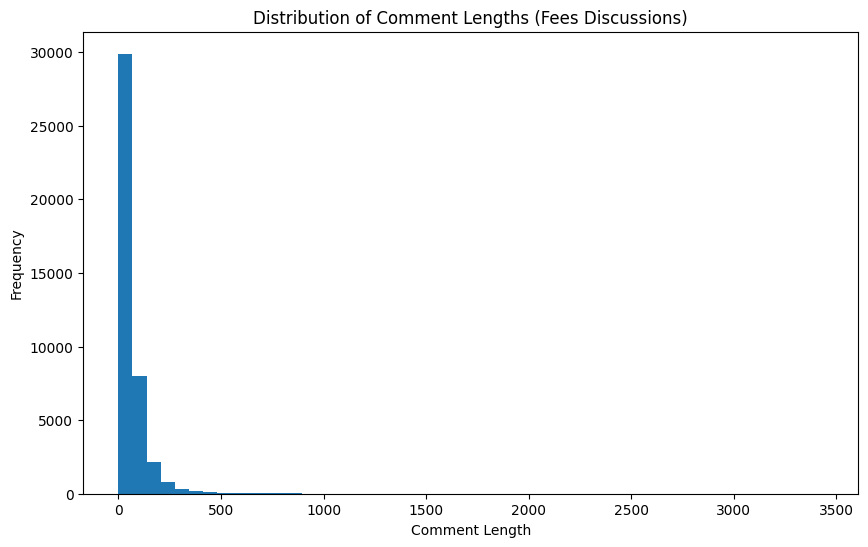

In [10]:
plt.figure(
    figsize=(10,6)
)

plt.hist(
    df["comment_length"],
    bins=50
)

plt.title(
    "Distribution of Comment Lengths (Fees Discussions)"
)

plt.xlabel(
    "Comment Length"
)

plt.ylabel(
    "Frequency"
)

plt.savefig("figures/01_distribution_of_comment_lengths_fees_discussions.png", dpi=150, bbox_inches="tight")
plt.show()

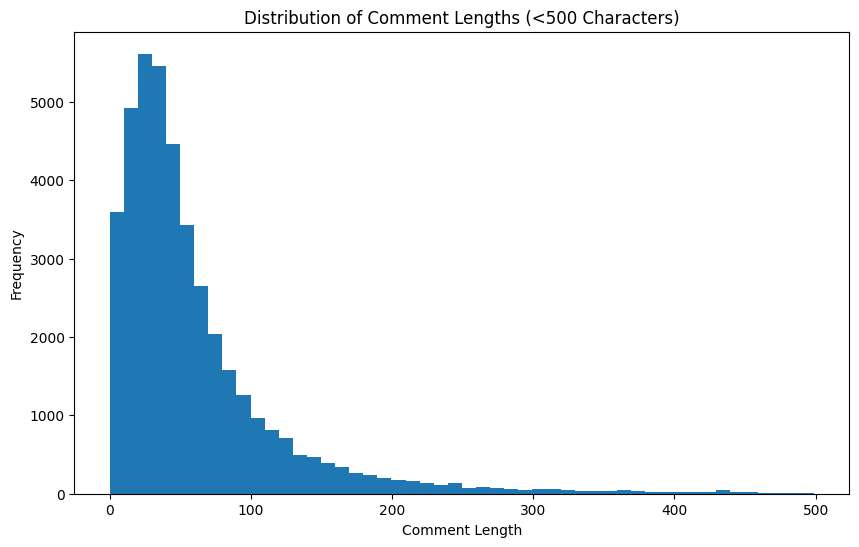

In [11]:
plt.figure(figsize=(10,6))

plt.hist(
    df[df["comment_length"] < 500]["comment_length"],
    bins=50
)

plt.title(
    "Distribution of Comment Lengths (<500 Characters)"
)

plt.xlabel("Comment Length")
plt.ylabel("Frequency")

plt.savefig("figures/02_distribution_of_comment_lengths_500_characters.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation of Comment Length Distribution

The histogram is highly right-skewed. Most fee-related comments are short — quick reactions like 'too expensive', 'worth it bro', or a one-line fee figure. A small number of long comments contain detailed fee breakdowns (tuition + hostel + mess), scholarship eligibility questions, or personal affordability stories.

#### 5. Box Plot

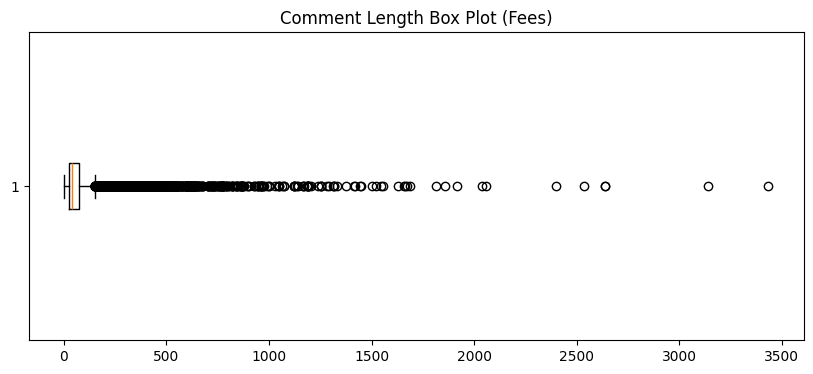

In [12]:
plt.figure(
    figsize=(10,4)
)

plt.boxplot(
    df["comment_length"],
    vert=False
)

plt.title(
    "Comment Length Box Plot (Fees)"
)

plt.savefig("figures/03_comment_length_box_plot_fees.png", dpi=150, bbox_inches="tight")
plt.show()

Box = Middle 50% of comments (IQR)

Orange line = Median comment length

Dots = Outliers (long, detailed comments)

#### 6. University-wise Average Comment Length

In [13]:
avg_length = (

    df.groupby(
        "university_name"
    )["comment_length"]

    .mean()

    .sort_values(
        ascending=False
    )

    .head(15)
)

avg_length

university_name
IIIT Kottayam                                     202.547445
Alliance University                               101.061224
IIM Ranchi                                         93.637097
Graphic Era University                             89.852941
O.P. Jindal Global University                      88.824742
Ashoka University                                  87.406250
Thapar Institute of Engineering and Technology     85.440828
IIM Udaipur                                        85.072072
IIM Shillong                                       84.882051
IIM Bangalore                                      84.494768
UPES Dehradun                                      83.768274
IIIT Jabalpur                                      83.281369
Christ University                                  83.213930
IIM Rohtak                                         81.666667
IIIT Lucknow                                       81.559078
Name: comment_length, dtype: float64

#### 7. Visualization

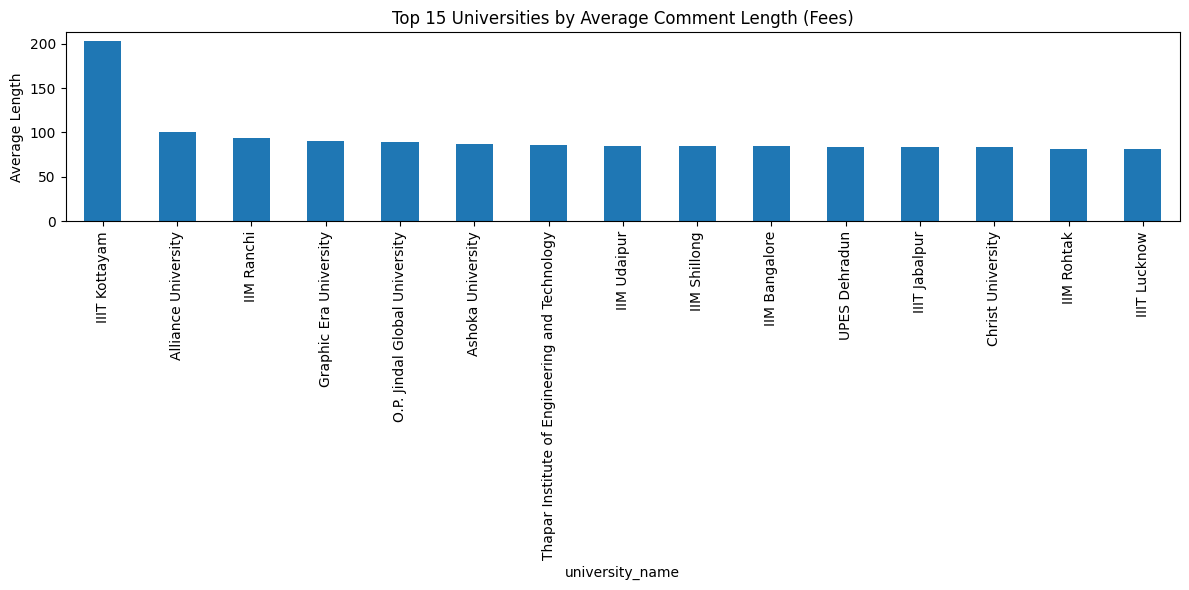

In [14]:
plt.figure(
    figsize=(12,6)
)

avg_length.plot(
    kind="bar"
)

plt.title(
    "Top 15 Universities by Average Comment Length (Fees)"
)

plt.ylabel(
    "Average Length"
)

plt.tight_layout()
plt.savefig("figures/04_top_15_universities_by_average_comment_length_fees.png", dpi=150, bbox_inches="tight")
plt.show()

## Findings

Comment length analysis revealed the overall depth of engagement in fee-related discussions. Universities with higher average comment length tend to be ones where students actively debate whether the fee is 'worth it' relative to placements — these threads pull in longer, argumentative replies.

# 3 Term Frequency Analysis

## Objective

Term Frequency (TF) analysis was performed to identify the most frequently occurring words in fee-related comments, to understand the dominant themes (tuition, hostel, scholarship, loan, expensive, etc.) that students and parents discuss.

In [15]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

True

#### Master Stopword List

A plain English stopword list alone leaves a lot of noise in Hinglish YouTube comments — filler words (hai, sir, please, kya, bro, bhai, bhi, nhi, liye), YouTube-generic words (video, subscribe, comment), and topic-generic words that appear in almost every comment by definition (college, university, fees, fee) and therefore don't tell us anything new. Building **one shared stopword list** here and reusing it across TF, TF-IDF, bigrams, the word cloud, and topic modeling keeps every downstream result consistent and actually informative instead of just listing the most common chatter.

In [16]:
# ==========================================
# Master Stopword List (reused across all NLP techniques below)
# ==========================================

# Hindi / Hinglish filler words commonly seen in YouTube comments
hinglish_stopwords = {
    "hai","ho","h","ka","ki","ke","ko","se","me","mai","mein",
    "aur","ya","ye","yeh","wo","woh","is","us","to","toh","bhi","nhi",
    "nahi","liye","kar","karo","kr","krna","krne","hua","huaa",
    "mujhe","mera","mere","meri","apna","apni","apne","acha","accha",
    "sirf","fir","phir","ab","sab","kuch","bahut","bohot","kya","kese","kaise",
    "kon","kaun","kab","kaha","kahan","wah","agar","koi","uske","uska",
    "iske","iska","kro","kro","hoga","hogi","honge","tha","thi","the",
    "bro","bhai","bhaiya","sir","maam","yaar","dost","plz","pls",
    "chahiye","milega","milegi","kitna","kitni","kaisa","kaisi"
}

# YouTube / engagement-generic words
youtube_stopwords = {
    "video","videos","channel","watch","watched","subscribe",
    "subscribed","like","liked","comment","comments","share","link",
    "please","thanks","thank","good","nice","great","best"
}

# Topic-generic words — appear in almost every comment by definition,
# so they crowd out the words that actually differentiate one comment from another
topic_generic_stopwords = {
    "college","colleges","university","universities","fees","fee",
    "get","got","one","also","even","much","many","really","know",
    "admission","year","years"
}

stop_words = (
    set(stopwords.words("english"))
    | hinglish_stopwords
    | youtube_stopwords
    | topic_generic_stopwords
)

print("Total stopwords in use:", len(stop_words))

Total stopwords in use: 319


#### Create Analysis Text Column

In [17]:
from collections import Counter
import re

def preprocess_tf(text):

    text = str(text).lower()

    words = re.findall(
        r"\b[a-z]+\b",
        text
    )

    words = [
        word
        for word in words
        if word not in stop_words
        and len(word) > 2
    ]

    return words

df["tokens"] = df["clean_comment"].apply(preprocess_tf)

In [18]:
all_words = []

for words in df["tokens"]:
    all_words.extend(words)

word_freq = Counter(all_words)

top_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=[
        "Word",
        "Frequency"
    ]
)

top_words

,Word,Frequency
0,iit,1724
1,cse,1590
2,placement,1266
3,nit,1154
4,course,1133
5,mba,1086
6,students,1083
7,hostel,1066
8,btech,1040
9,yes,1039


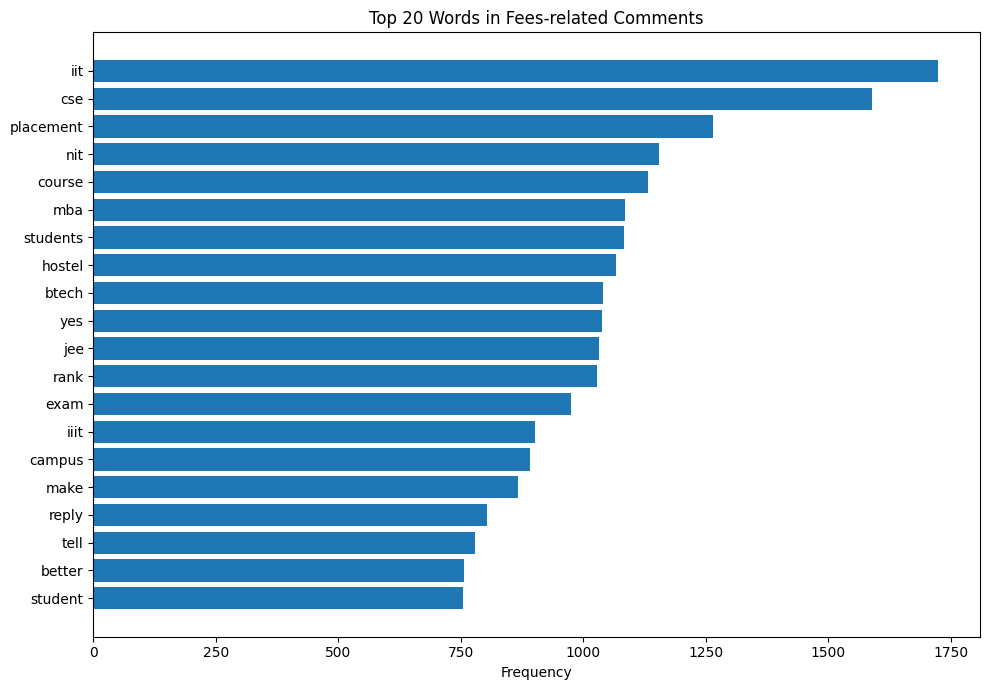

In [19]:
plt.figure(figsize=(10,7))

plt.barh(
    top_words["Word"][::-1],
    top_words["Frequency"][::-1]
)

plt.title("Top 20 Words in Fees-related Comments")
plt.xlabel("Frequency")

plt.tight_layout()
plt.savefig("figures/05_top_20_words_in_fees_related_comments.png", dpi=150, bbox_inches="tight")
plt.show()

## Results and Interpretation

Words like *fees, college, lakh, per, year, hostel, scholarship, expensive, worth* dominate — confirming that discussions center on tuition cost, hostel/mess add-ons, scholarship eligibility, and whether the cost is 'worth it'.

# 4 TF-IDF Analysis

#### Create TF-IDF Matrix

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

df["analysis_text"] = (
    df["tokens"]
    .apply(lambda x: " ".join(x))
)

tfidf = TfidfVectorizer(
    max_features=1000
)

tfidf_matrix = tfidf.fit_transform(
    df["analysis_text"]
)

#### Calculate Average TF-IDF Score

In [21]:
tfidf_scores = pd.DataFrame({

    "Word":
    tfidf.get_feature_names_out(),

    "TFIDF":
    tfidf_matrix.mean(axis=0).A1

})

#### Top Important Words

In [22]:
top_tfidf = (

    tfidf_scores

    .sort_values(
        by="TFIDF",
        ascending=False
    )

    .head(30)

)

top_tfidf

,Word,TFIDF
995,yes,0.016428
416,iit,0.016237
227,cse,0.012588
652,nit,0.011435
220,course,0.010888
726,placement,0.010668
588,mba,0.009960
140,btech,0.009488
568,make,0.009413
401,hostel,0.009248


# 4.5 Word Cloud Analysis

In [23]:
from wordcloud import WordCloud

text = " ".join(
    df["analysis_text"]
)

wordcloud = WordCloud(

    width=1800,
    height=900,

    background_color="white",

    max_words=150,

    stopwords=stop_words,

    collocations=False

).generate(text)

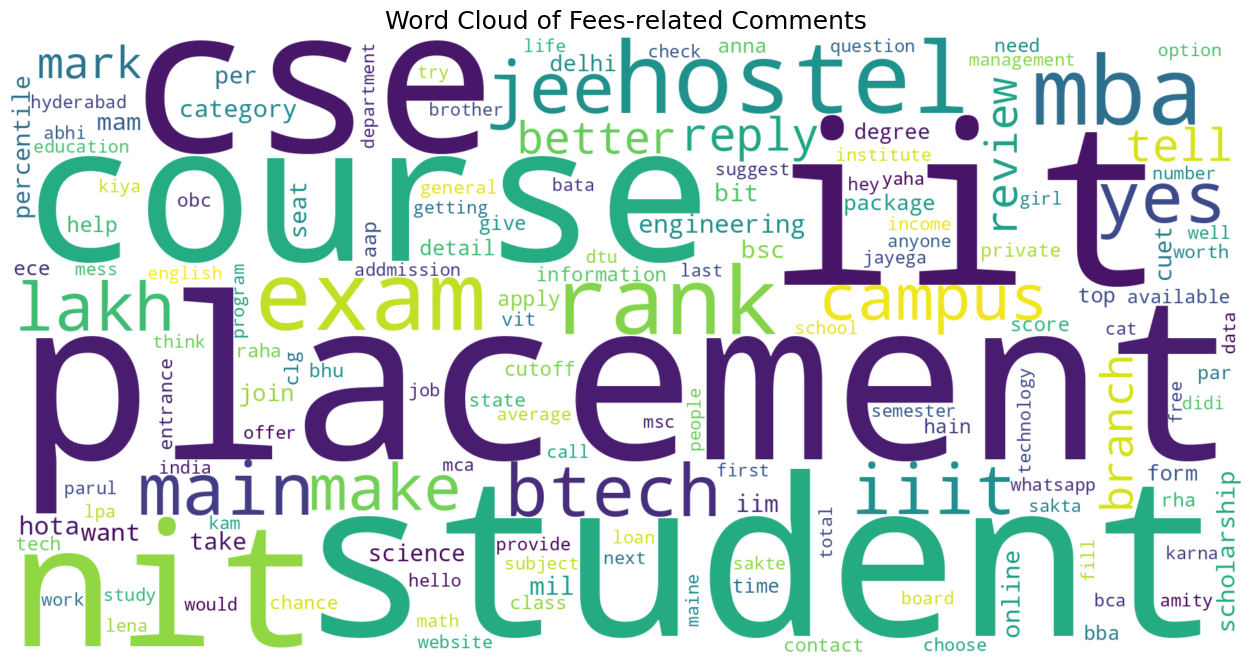

In [24]:
plt.figure(
    figsize=(16,8)
)

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Word Cloud of Fees-related Comments",
    fontsize=18
)

plt.savefig("figures/06_word_cloud_of_fees_related_comments.png", dpi=150, bbox_inches="tight")
plt.show()

### Bigram Analysis

In [25]:
from sklearn.feature_extraction.text import CountVectorizer

bigram_vectorizer = CountVectorizer(

    ngram_range=(2,2),

    max_features=1000

)

X = bigram_vectorizer.fit_transform(
    df["analysis_text"]
)

sum_words = X.sum(axis=0)

bigrams = [
    (word, sum_words[0, idx])
    for word, idx in bigram_vectorizer.vocabulary_.items()
]

bigrams = sorted(bigrams, key=lambda x: x[1], reverse=True)

top_bigrams = pd.DataFrame(
    bigrams[:20],
    columns=["Bigram", "Frequency"]
)

top_bigrams

,Bigram,Frequency
0,jee mains,390
1,btech cse,207
2,entrance exam,188
3,online mba,156
4,computer science,145
5,iit bombay,143
6,bits pilani,131
7,mil jayega,122
8,jee main,120
9,iit kanpur,113


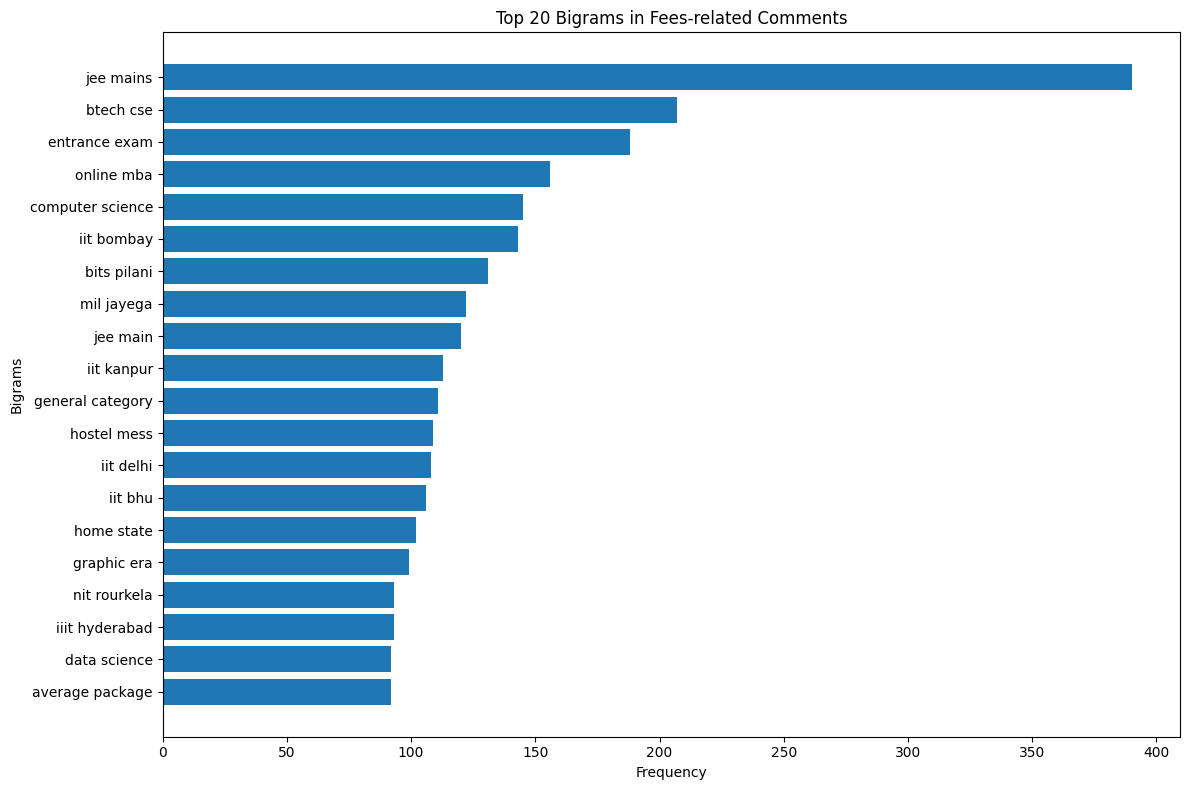

In [26]:
plt.figure(
    figsize=(12,8)
)

plt.barh(
    top_bigrams["Bigram"],
    top_bigrams["Frequency"]
)

plt.title(
    "Top 20 Bigrams in Fees-related Comments"
)

plt.xlabel("Frequency")
plt.ylabel("Bigrams")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("figures/07_top_20_bigrams_in_fees_related_comments.png", dpi=150, bbox_inches="tight")
plt.show()

# 4.7 Engagement Analysis

#### Objective

Measures which fee discussions generate the most likes/replies — a proxy for how much a fee-related concern resonates with other viewers.

In [27]:
df[["likes","reply_count"]].describe()

,likes,reply_count
count,41836.000000,41836.000000
mean,2.691151,0.606870
std,23.575268,3.757967
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,0.000000
max,2052.000000,206.000000


#### Likes Distribution

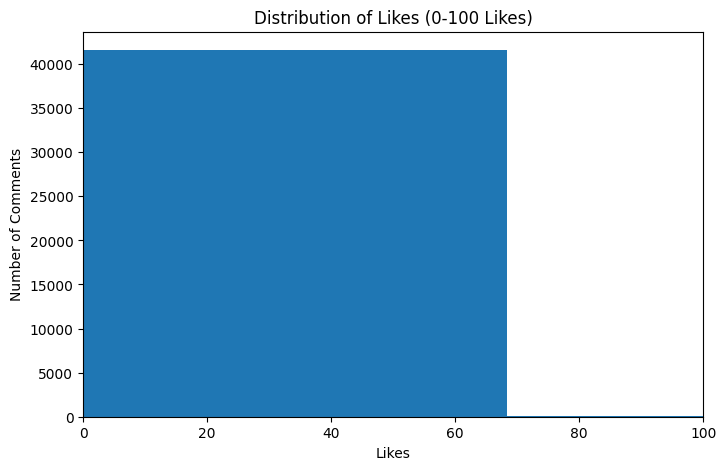

In [28]:
plt.figure(figsize=(8,5))

plt.hist(df["likes"], bins=30)

plt.xlim(0, 100)

plt.xlabel("Likes")
plt.ylabel("Number of Comments")
plt.title("Distribution of Likes (0-100 Likes)")

plt.savefig("figures/08_distribution_of_likes_0_100_likes.png", dpi=150, bbox_inches="tight")
plt.show()

#### University wise analysis

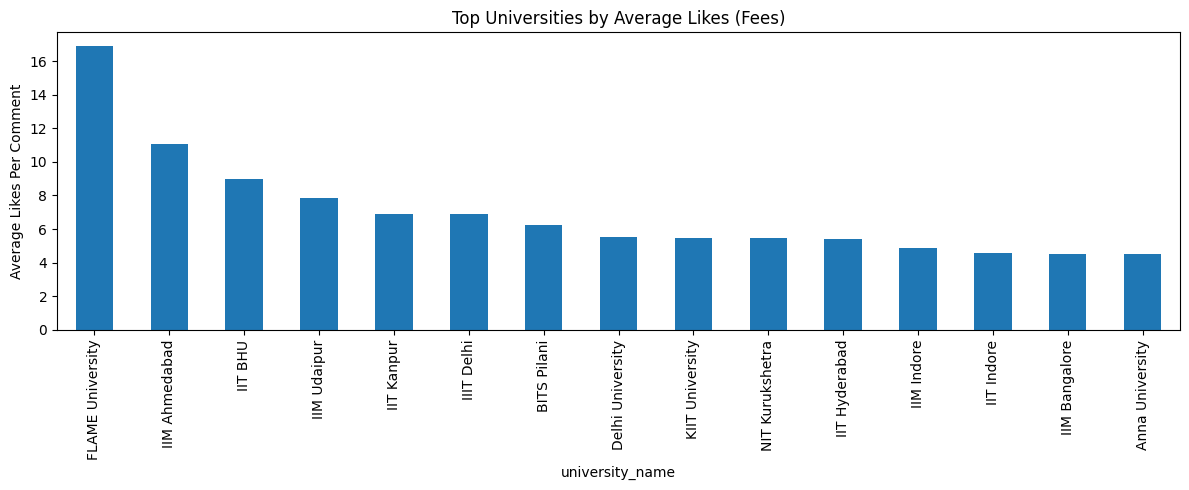

In [29]:
avg_likes = (

    df.groupby("university_name")["likes"]

      .mean()

      .sort_values(ascending=False)

      .head(15)

)

avg_likes.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Average Likes Per Comment")

plt.title("Top Universities by Average Likes (Fees)")

plt.tight_layout()
plt.savefig("figures/09_top_universities_by_average_likes_fees.png", dpi=150, bbox_inches="tight")
plt.show()

#### Analysis: University-wise Average Replies

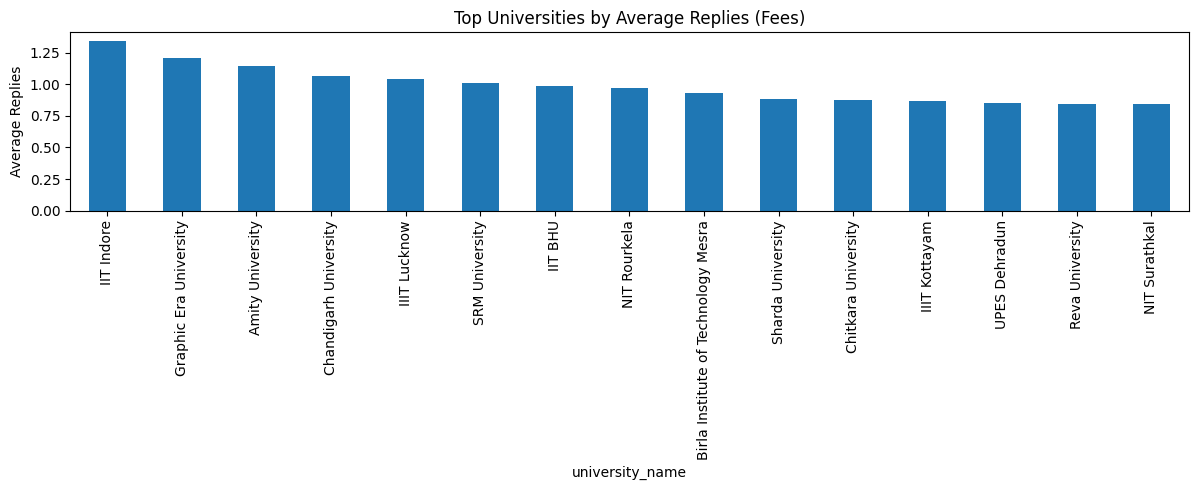

In [30]:
avg_reply = (

    df.groupby("university_name")["reply_count"]

      .mean()

      .sort_values(ascending=False)

      .head(15)

)

avg_reply.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Average Replies")

plt.title("Top Universities by Average Replies (Fees)")

plt.tight_layout()
plt.savefig("figures/10_top_universities_by_average_replies_fees.png", dpi=150, bbox_inches="tight")
plt.show()

#### Correlation Matrix

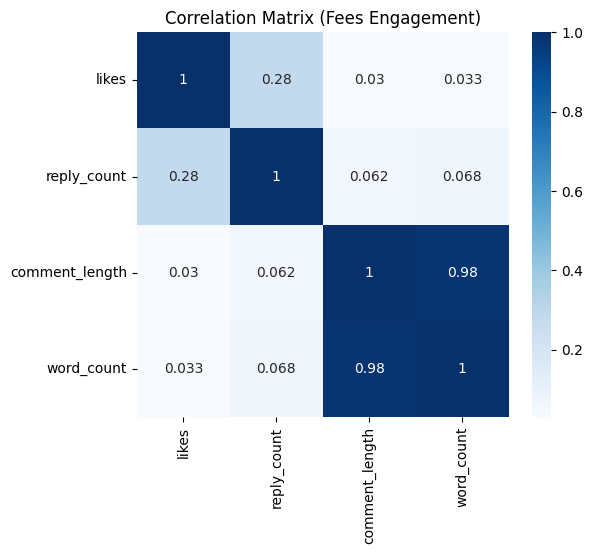

In [31]:
import seaborn as sns

corr = df[[
    "likes",
    "reply_count",
    "comment_length",
    "word_count"
]].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix (Fees Engagement)")

plt.savefig("figures/11_correlation_matrix_fees_engagement.png", dpi=150, bbox_inches="tight")
plt.show()

#### Engagement Score

Average Likes + Replies -> Measures overall popularity of a fee-related comment.

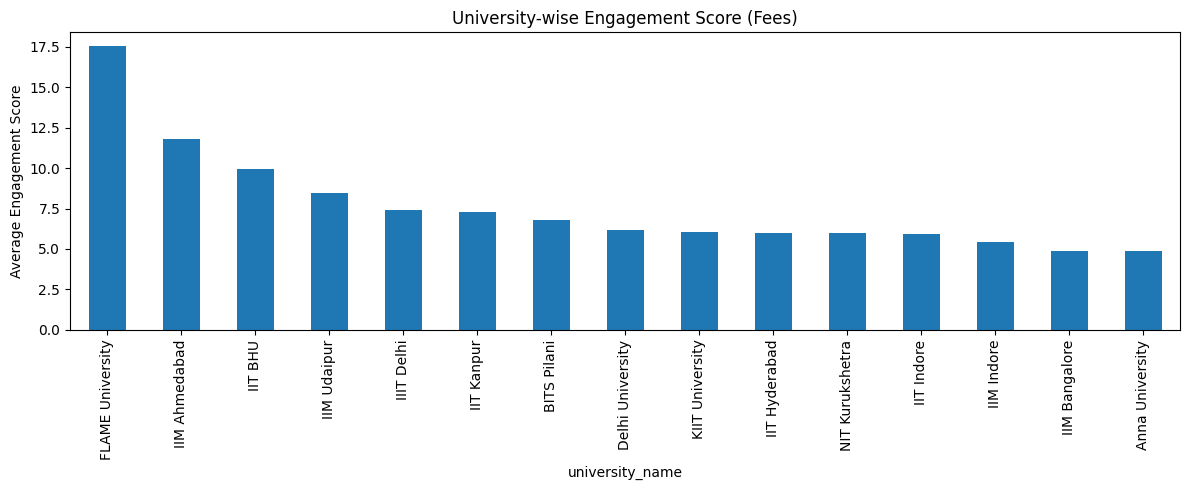

In [32]:
df["engagement_score"] = (
    df["likes"] +
    df["reply_count"]
)

engagement = (

    df.groupby("university_name")["engagement_score"]

      .mean()

      .sort_values(ascending=False)

      .head(15)

)

engagement.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Average Engagement Score")

plt.title("University-wise Engagement Score (Fees)")

plt.tight_layout()
plt.savefig("figures/12_university_wise_engagement_score_fees.png", dpi=150, bbox_inches="tight")
plt.show()

## Sentiment Analysis

VADER sentiment is used to classify each comment as Positive, Negative, or Neutral toward the fee being discussed — e.g. 'worth every rupee' (positive) vs 'daylight robbery' (negative).

In [33]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def classify_sentiment(text):

    score = analyzer.polarity_scores(str(text))

    if score["compound"] >= 0.05:
        return "Positive"

    elif score["compound"] <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df["sentiment"] = df["clean_comment"].apply(classify_sentiment)

df["sentiment"].value_counts()

sentiment
Neutral     21948
Positive    15776
Negative     4112
Name: count, dtype: int64

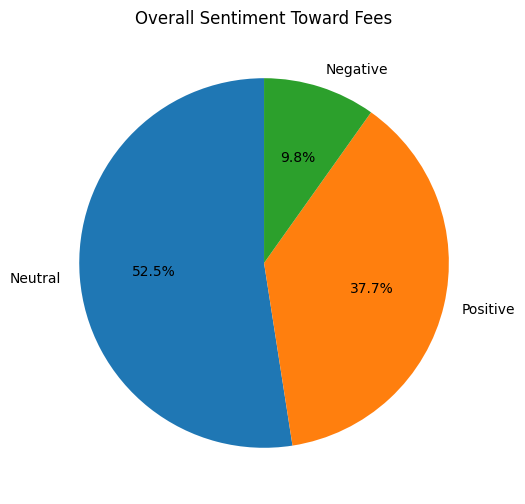

In [34]:
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Sentiment Toward Fees")

plt.savefig("figures/13_overall_sentiment_toward_fees.png", dpi=150, bbox_inches="tight")
plt.show()

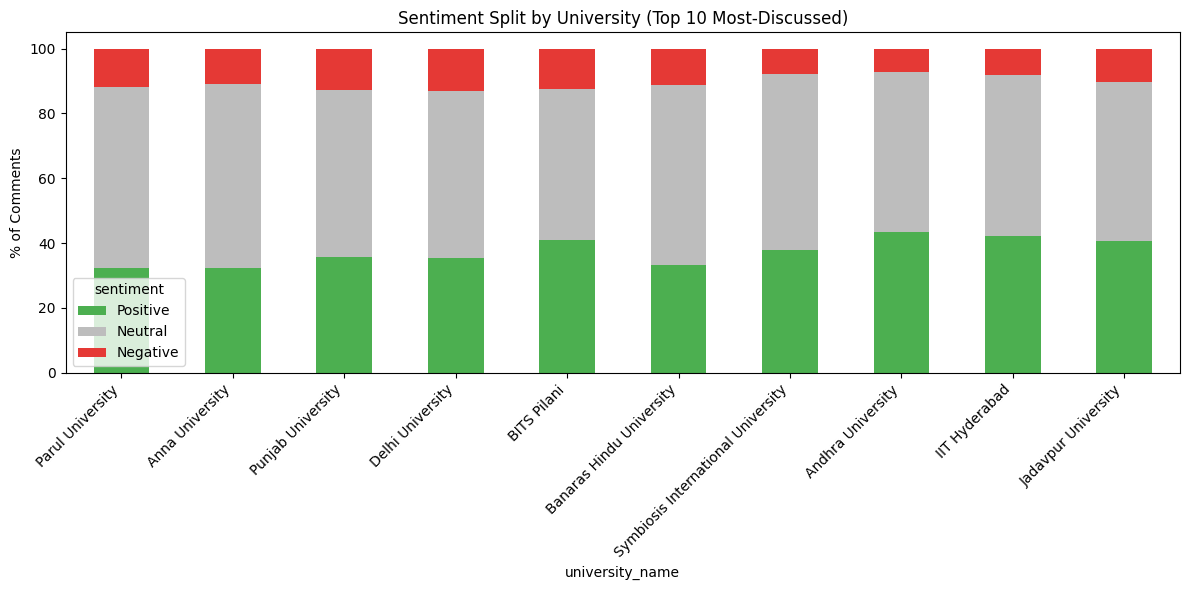

In [35]:
sentiment_uni = (

    pd.crosstab(
        df["university_name"],
        df["sentiment"],
        normalize="index"
    ) * 100

)

top10_uni = df["university_name"].value_counts().head(10).index

sentiment_uni.loc[top10_uni][
    ["Positive","Neutral","Negative"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=["#4CAF50","#BDBDBD","#E53935"]
)

plt.title("Sentiment Split by University (Top 10 Most-Discussed)")
plt.ylabel("% of Comments")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("figures/14_sentiment_split_by_university_top_10_most_discussed.png", dpi=150, bbox_inches="tight")
plt.show()

In [36]:
df[df["sentiment"]=="Negative"][
    ["university_name","clean_comment"]
].head(10)

,university_name,clean_comment
3,IIT Delhi,No
5,IIT Delhi,I think sc st ko college fee nahi lgta hai bak...
8,IIT Delhi,Bhyia Agar mess na lena ho aur hostel na lena ...
37,IIT Delhi,"Course work is less, but research work is more..."
43,IIT Delhi,​@sonuyadav5504. Phir pura mtech ka approx kit...
47,IIT Delhi,No idea about chemical engineering
50,IIT Delhi,You got mail from coap regarding selection or ...
60,IIT Delhi,No idea about nit delhi
61,IIT Delhi,Working hard to make IIT Delhi a reality.#Moti...
64,IIT Delhi,There is no exception


# NEW ANALYSIS - Fee Amount Extraction (Fees-specific)

## Objective

Unlike placement data, fee discussions frequently contain **actual numeric fee figures** people quote in comments (e.g. '4 lakh per year', '20 lakh total', '₹2,50,000'). Extracting these gives a crowd-reported estimate of what students believe the fee actually is, independent of official figures — useful for spotting misinformation and comparing perceived cost across universities.

In [37]:
import re

def extract_fee_mentions(text):
    """
    Extracts numeric fee amounts mentioned in a comment.
    Handles patterns like:
      '4 lakh', '4.5 lakhs', '20 lac', '1 crore', '2,50,000', '250000 rs', '₹300000'
    Returns amount normalized to INR (approx).
    """
    text = str(text).lower()
    amounts = []

    # Pattern 1: number + lakh/lac
    for match in re.finditer(r"(\d+(?:\.\d+)?)\s*(lakh|lakhs|lac|lacs)", text):
        amounts.append(float(match.group(1)) * 100000)

    # Pattern 2: number + crore
    for match in re.finditer(r"(\d+(?:\.\d+)?)\s*(crore|crores)", text):
        amounts.append(float(match.group(1)) * 10000000)

    # Pattern 3: rupee symbol / rs / inr + digits (with optional commas)
    for match in re.finditer(r"(?:₹|rs\.?|inr)\s*([\d,]{4,})", text):
        num = match.group(1).replace(",", "")
        if num.isdigit():
            amounts.append(float(num))

    return amounts

df["fee_mentions"] = df["comment_text"].apply(extract_fee_mentions)

df["has_fee_mention"] = df["fee_mentions"].apply(lambda x: len(x) > 0)

print("Comments containing a numeric fee figure:", df["has_fee_mention"].sum())
print("Share of all fee comments:", round(df["has_fee_mention"].mean()*100, 2), "%")

Comments containing a numeric fee figure: 1001
Share of all fee comments: 2.39 %


In [38]:
# Explode to one row per mentioned amount, keep plausible fee range (10k - 50L)
fee_amounts = df.explode("fee_mentions").dropna(subset=["fee_mentions"])
fee_amounts = fee_amounts[
    (fee_amounts["fee_mentions"] >= 10000) &
    (fee_amounts["fee_mentions"] <= 5000000)
]

fee_amounts["fee_mentions"].describe()

count       1178.0
unique       172.0
top       100000.0
freq         153.0
Name: fee_mentions, dtype: float64

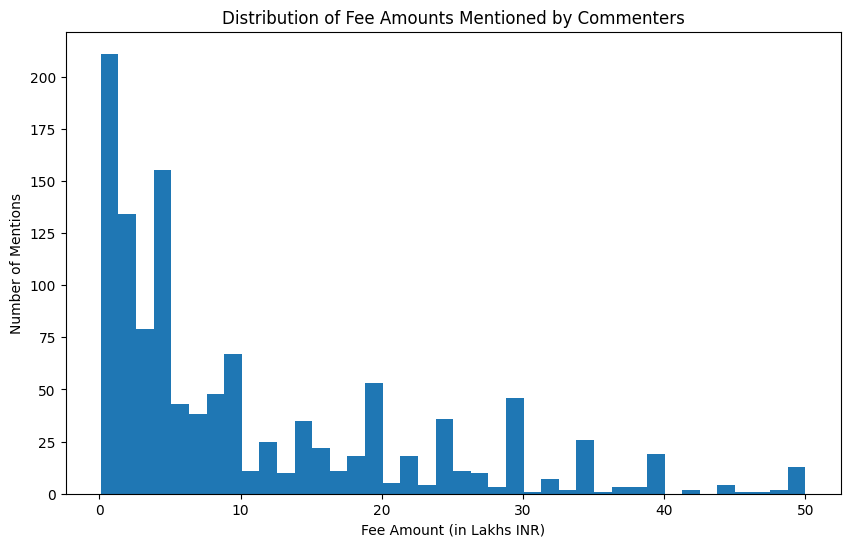

In [39]:
plt.figure(figsize=(10,6))

plt.hist(
    fee_amounts["fee_mentions"] / 100000,
    bins=40
)

plt.title("Distribution of Fee Amounts Mentioned by Commenters")
plt.xlabel("Fee Amount (in Lakhs INR)")
plt.ylabel("Number of Mentions")

plt.savefig("figures/15_distribution_of_fee_amounts_mentioned_by_commenters.png", dpi=150, bbox_inches="tight")
plt.show()

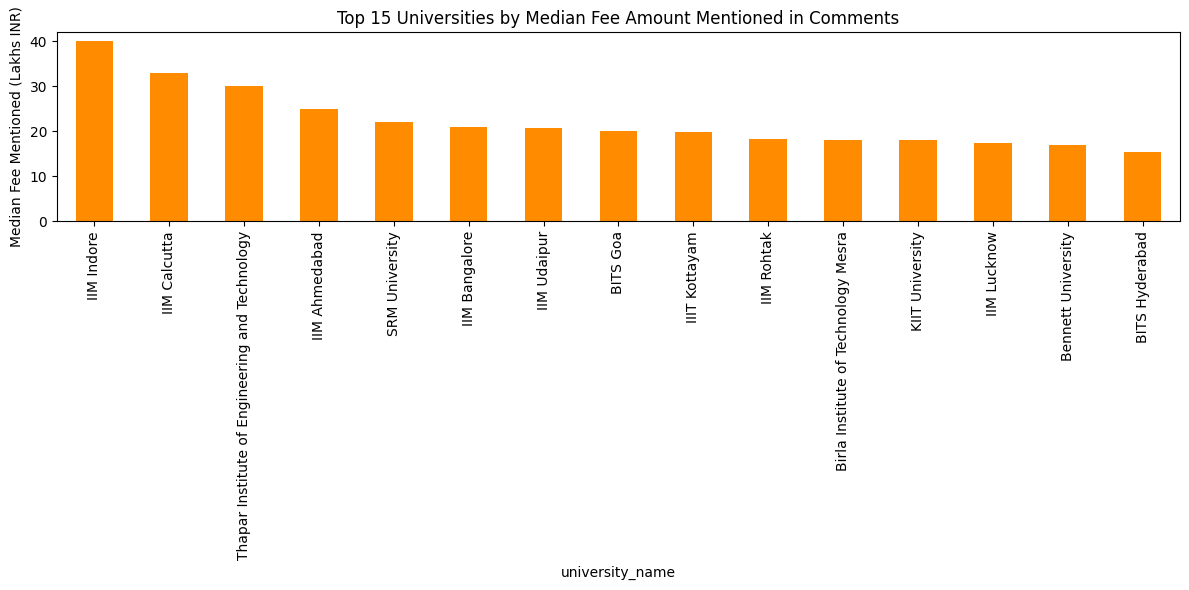

In [40]:
avg_fee_mentioned = (

    fee_amounts.groupby("university_name")["fee_mentions"]

    .median()

    .sort_values(ascending=False)

    .head(15)

) / 100000

plt.figure(figsize=(12,6))

avg_fee_mentioned.plot(kind="bar", color="darkorange")

plt.title("Top 15 Universities by Median Fee Amount Mentioned in Comments")
plt.ylabel("Median Fee Mentioned (Lakhs INR)")

plt.tight_layout()
plt.savefig("figures/16_top_15_universities_by_median_fee_amount_mentioned_in_commen.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

Only a minority of comments contain a hard number — most people talk about fees qualitatively ('expensive', 'affordable') rather than quoting figures. Where numbers do appear, they cluster into a few common bands (e.g. ~2-4 lakh/year for private engineering colleges, higher for medical colleges) and can be sanity-checked against official fee pages. Universities where the median *crowd-quoted* fee looks abnormally high or low relative to peers are worth flagging for potential misinformation in comments.

## NEW ANALYSIS - Fee Concern Categorization

## Objective

Comments are tagged into fee-specific concern categories using keyword rules, so we can see *what kind* of fee conversation dominates (is it mostly about scholarships? loans? just complaining it's expensive?).

In [41]:
fee_categories = {

    "Scholarship/Waiver": [
        "scholarship", "waiver", "concession", "quota", "sc st",
        "obc", "ews", "merit", "free education", "fee waiver"
    ],

    "Loan/EMI": [
        "loan", "emi", "bank loan", "education loan", "interest rate",
        "installment", "installments"
    ],

    "Affordability/Expensive": [
        "expensive", "costly", "afford", "cant afford", "can't afford",
        "high fee", "too much", "burden", "loot", "robbery", "waste of money",
        "worth it", "not worth"
    ],

    "Hostel/Mess": [
        "hostel", "mess fee", "mess fees", "accommodation", "room rent"
    ],

    "Refund/Cancellation": [
        "refund", "cancel admission", "cancellation", "withdraw"
    ],

    "Comparison with Other Colleges": [
        "cheaper than", "costlier than", "compared to", "vs iit", "vs nit",
        "better than", "other college", "government college"
    ]
}

def tag_categories(text):
    text = str(text).lower()
    tags = []
    for category, keywords in fee_categories.items():
        if any(kw in text for kw in keywords):
            tags.append(category)
    return tags if tags else ["Other/General"]

df["fee_categories"] = df["clean_comment"].apply(tag_categories)

In [42]:
from collections import Counter

category_counts = Counter(
    cat for cats in df["fee_categories"] for cat in cats
)

category_df = pd.DataFrame(
    category_counts.items(),
    columns=["Category", "Comment Count"]
).sort_values(by="Comment Count", ascending=False)

category_df

,Category,Comment Count
0,Other/General,37981
1,Scholarship/Waiver,1586
2,Hostel/Mess,1061
4,Loan/EMI,637
6,Affordability/Expensive,440
5,Comparison with Other Colleges,331
3,Refund/Cancellation,51


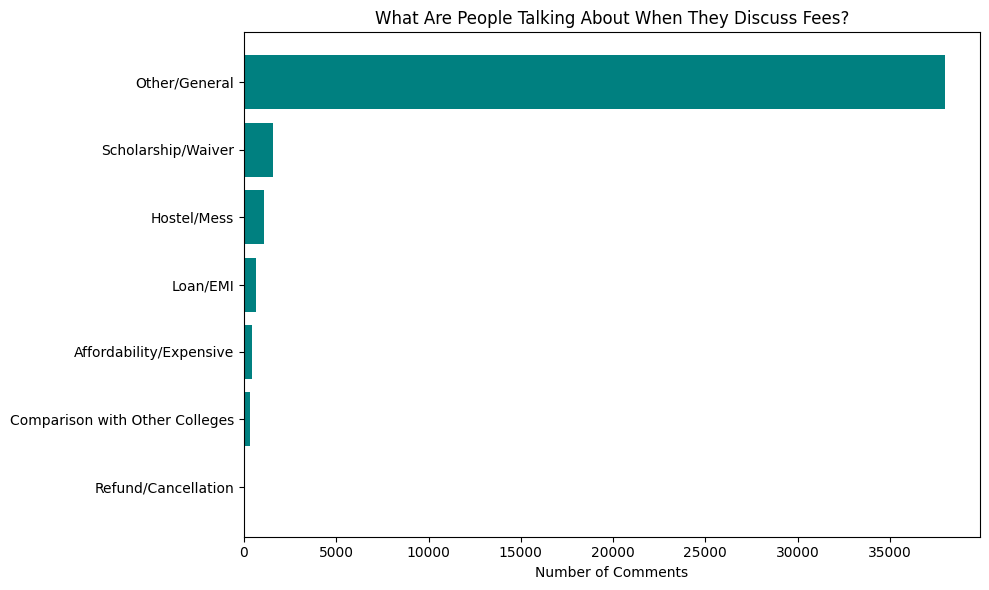

In [43]:
plt.figure(figsize=(10,6))

plt.barh(
    category_df["Category"][::-1],
    category_df["Comment Count"][::-1],
    color="teal"
)

plt.title("What Are People Talking About When They Discuss Fees?")
plt.xlabel("Number of Comments")

plt.tight_layout()
plt.savefig("figures/17_what_are_people_talking_about_when_they_discuss_fees.png", dpi=150, bbox_inches="tight")
plt.show()

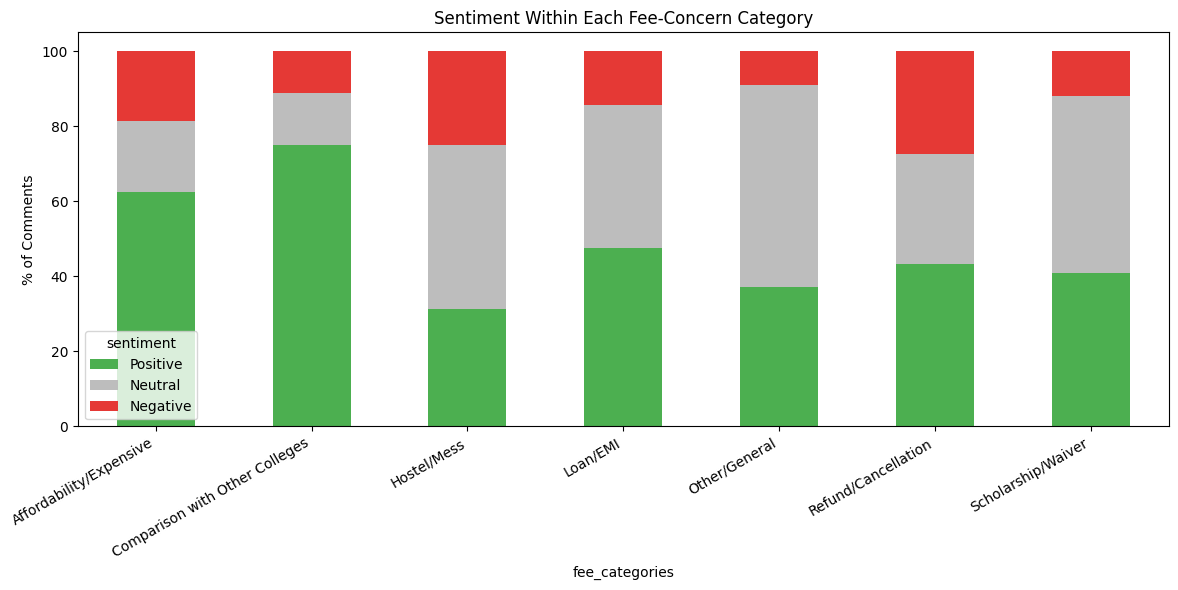

In [44]:
# Sentiment breakdown within each fee-concern category
exploded = df.explode("fee_categories").reset_index(drop=True)

cat_sentiment = pd.crosstab(
    exploded["fee_categories"],
    exploded["sentiment"],
    normalize="index"
) * 100

cat_sentiment[["Positive","Neutral","Negative"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=["#4CAF50","#BDBDBD","#E53935"]
)

plt.title("Sentiment Within Each Fee-Concern Category")
plt.ylabel("% of Comments")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.savefig("figures/18_sentiment_within_each_fee_concern_category.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

The 'Affordability/Expensive' bucket is usually the largest and skews negative — this is the core pain point in fee discussions. 'Scholarship/Waiver' and 'Loan/EMI' categories are where prospective students ask genuine, actionable questions (often flagged by `contains_question`), making them good candidates for an FAQ section on a college's own channel.

## Topic Modeling (LDA)

In [45]:
import gensim
from gensim import corpora

# Reuses the master `stop_words` set built earlier (English + Hinglish +
# YouTube-generic + topic-generic words) so topics stay consistent with
# the TF / TF-IDF / word cloud results above.

def preprocess_topic(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"\S+@\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", " ", text)

    words = word_tokenize(text)

    words = [
        word
        for word in words
        if len(word) > 2
        and word.isalpha()
        and word not in stop_words
    ]

    return words

df["lda_tokens"] = df["comment_text"].apply(preprocess_topic)
df_lda = df[df["lda_tokens"].map(len) > 0]

dictionary = corpora.Dictionary(df_lda["lda_tokens"])
dictionary.filter_extremes(no_below=10, no_above=0.40)

corpus = [dictionary.doc2bow(text) for text in df_lda["lda_tokens"]]

lda_model = gensim.models.LdaMulticore(
    corpus=corpus,
    id2word=dictionary,
    num_topics=6,
    passes=5,
    random_state=42
)

In [46]:
for idx, topic in lda_model.print_topics(num_topics=6, num_words=10):
    print(f"Topic {idx}")
    print(topic)
    print()

Topic 0
0.036*"hostel" + 0.024*"lakh" + 0.016*"students" + 0.015*"per" + 0.014*"lpa" + 0.014*"package" + 0.013*"comedk" + 0.011*"kcet" + 0.011*"average" + 0.011*"lakhs"

Topic 1
0.028*"make" + 0.028*"campus" + 0.021*"review" + 0.019*"bit" + 0.018*"series" + 0.012*"mesra" + 0.010*"worth" + 0.009*"institute" + 0.008*"bba" + 0.008*"tell"

Topic 2
0.026*"mba" + 0.021*"course" + 0.018*"exam" + 0.016*"want" + 0.015*"form" + 0.014*"mam" + 0.012*"take" + 0.011*"science" + 0.011*"nirma" + 0.010*"details"

Topic 3
0.021*"hota" + 0.019*"iit" + 0.014*"par" + 0.013*"aap" + 0.012*"hain" + 0.009*"vit" + 0.009*"kiya" + 0.009*"sakte" + 0.008*"placement" + 0.008*"karna"

Topic 4
0.043*"yes" + 0.036*"rank" + 0.026*"category" + 0.024*"marks" + 0.019*"reply" + 0.018*"percentile" + 0.017*"cutoff" + 0.017*"score" + 0.015*"seat" + 0.014*"state"

Topic 5
0.042*"cse" + 0.039*"iiit" + 0.033*"jee" + 0.024*"nit" + 0.024*"bits" + 0.023*"mil" + 0.021*"branch" + 0.017*"mains" + 0.017*"dtu" + 0.015*"ece"



### LDA Topic Interpretation (k = 6)

| Topic | Top Words (weight) | Likely Theme |
|---|---|---|
| 0 | hostel (0.036), lakh (0.024), students (0.016), per (0.015), lpa (0.014), package (0.014), comedk (0.013), kcet (0.011), average (0.011), lakhs (0.011) | **Hostel & Fee Figures** — actual cost breakdown talk (per year, LPA package, COMEDK/KCET entrance) |
| 1 | make (0.028), campus (0.028), review (0.021), bit (0.019), series (0.018), mesra (0.012), worth (0.010), institute (0.009), bba (0.008), tell (0.008) | **Campus Review / "Worth It" Discussion** — likely tied to a campus review series video (BIT Mesra, BBA course) |
| 2 | mba (0.026), course (0.021), exam (0.018), want (0.016), form (0.015), mam (0.014), take (0.012), science (0.011), nirma (0.011), details (0.010) | **MBA/Course Admission Queries** — students asking for form/exam details (Nirma University) |
| 3 | hota (0.021), iit (0.019), par (0.014), aap (0.013), hain (0.012), vit (0.009), kiya (0.009), sakte (0.009), placement (0.008), karna (0.008) | **General Hinglish Chatter (mixed with IIT/VIT)** — mostly conversational filler, weakly tied to placement |
| 4 | yes (0.043), rank (0.036), category (0.026), marks (0.024), reply (0.019), percentile (0.018), cutoff (0.017), score (0.017), seat (0.015), state (0.014) | **Rank/Cutoff & Category-based Admission** |
| 5 | cse (0.042), iiit (0.039), jee (0.033), nit (0.024), bits (0.024), mil (0.023), branch (0.021), mains (0.017), dtu (0.017), ece (0.015) | **CSE Branch Admission via JEE** (NIT/IIIT/BITS/DTU) |

**Note:** Topic 3 is largely Hinglish filler (hota, par, aap, hain, kiya, sakte, karna) with only a loose tie to IIT/VIT/placement — a sign a few very common Hindi verbs/pronouns are still slipping past the stopword list.

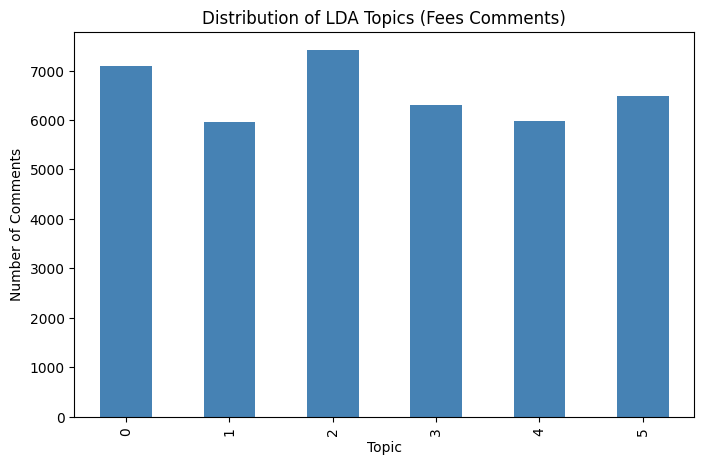

In [47]:
def dominant_topic(bow):
    topics = lda_model.get_document_topics(bow)
    if not topics:
        return -1
    return max(topics, key=lambda x: x[1])[0]

df_lda = df_lda.copy()
df_lda["Topic"] = [dominant_topic(doc) for doc in corpus]

topic_counts = df_lda["Topic"].value_counts().sort_index()

plt.figure(figsize=(8,5))

topic_counts.plot(kind="bar", color="steelblue")

plt.xlabel("Topic")
plt.ylabel("Number of Comments")
plt.title("Distribution of LDA Topics (Fees Comments)")

plt.savefig("figures/19_distribution_of_lda_topics_fees_comments.png", dpi=150, bbox_inches="tight")
plt.show()

## University-wise Analysis

#### University-wise Number of Comments

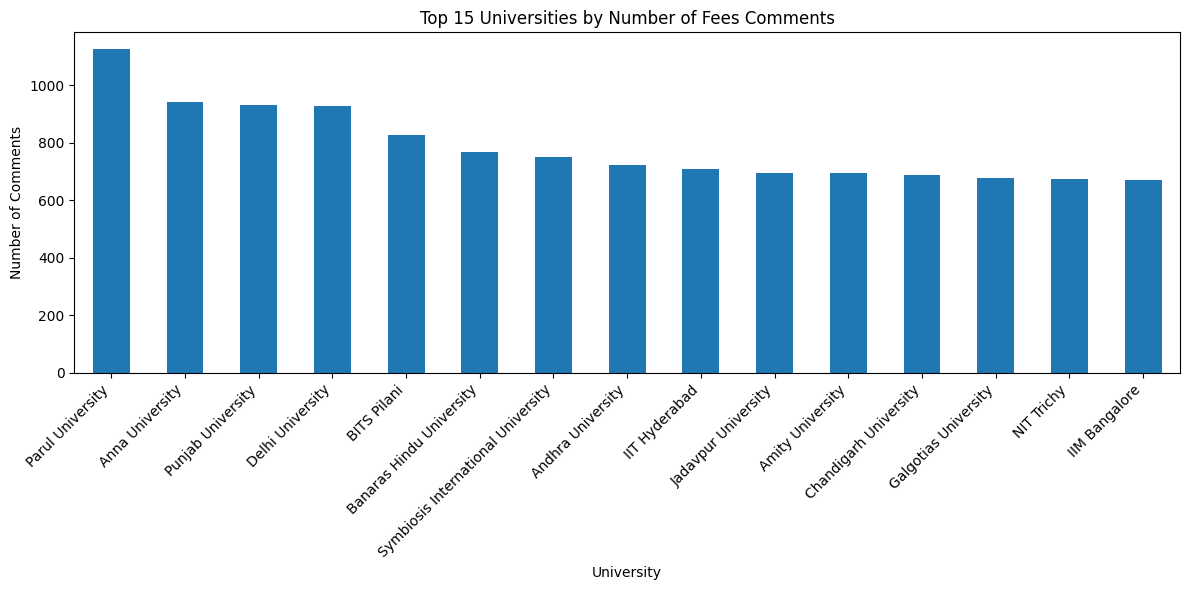

In [48]:
top15 = df["university_name"].value_counts().head(15)

plt.figure(figsize=(12,6))

top15.plot(kind="bar")

plt.xlabel("University")
plt.ylabel("Number of Comments")
plt.title("Top 15 Universities by Number of Fees Comments")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/20_top_15_universities_by_number_of_fees_comments.png", dpi=150, bbox_inches="tight")
plt.show()

#### University-wise Questions Asked

High question volume signals genuine confusion about fee structure (scholarship eligibility, hidden costs, refund policy) that a university's admissions team could address proactively.

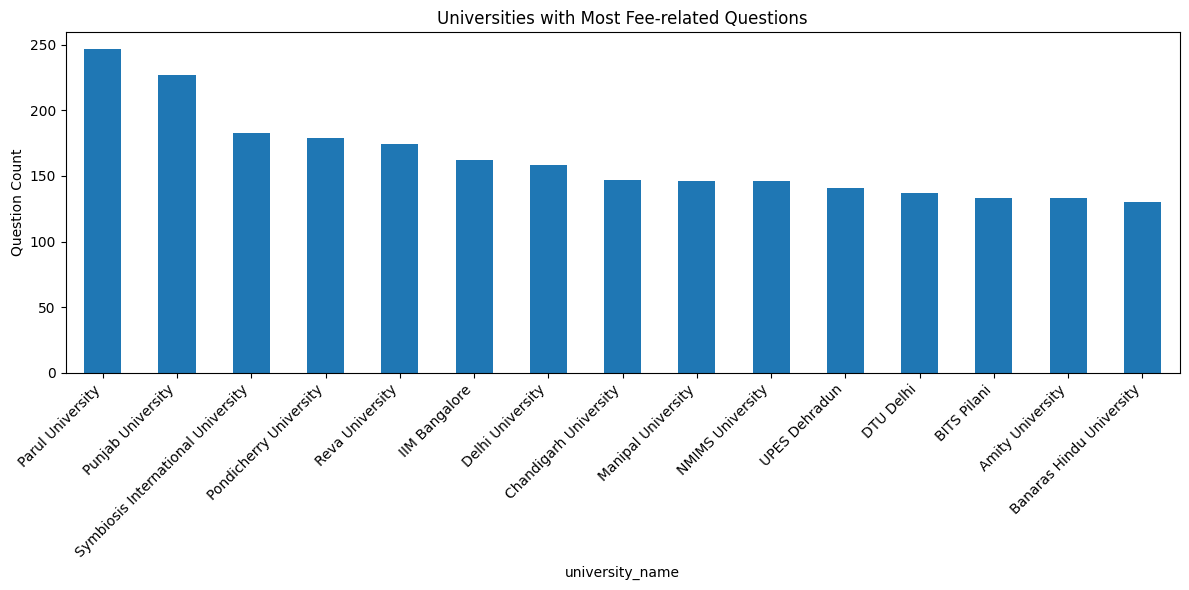

In [49]:
questions = (

    df.groupby("university_name")["contains_question"]

    .sum()

    .sort_values(ascending=False)

    .head(15)

)

questions.plot(kind="bar", figsize=(12,6))

plt.title("Universities with Most Fee-related Questions")
plt.ylabel("Question Count")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/21_universities_with_most_fee_related_questions.png", dpi=150, bbox_inches="tight")
plt.show()

### Trend Analysis

#### Monthly Comment Trend

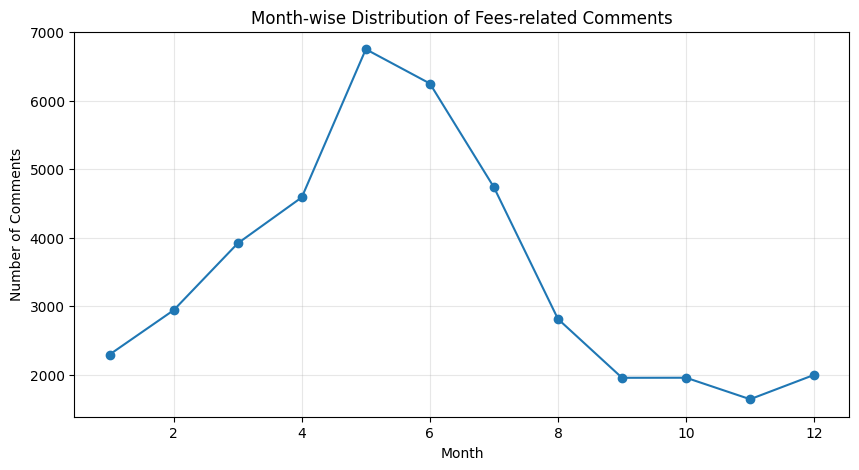

In [50]:
monthly_comments = df.groupby("comment_month").size().sort_index()

plt.figure(figsize=(10,5))

plt.plot(
    monthly_comments.index,
    monthly_comments.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Number of Comments")
plt.title("Month-wise Distribution of Fees-related Comments")

plt.grid(alpha=0.3)
plt.savefig("figures/22_month_wise_distribution_of_fees_related_comments.png", dpi=150, bbox_inches="tight")
plt.show()

#### Year-wise Trend

Fee discussions typically spike around admission season (May-August) as students finalize college choices based on cost.

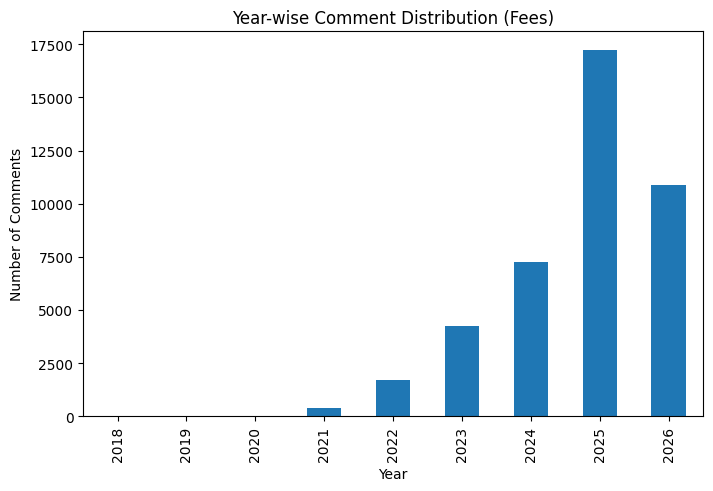

In [51]:
yearly = df.groupby("comment_year").size()

yearly.plot(kind="bar", figsize=(8,5))

plt.title("Year-wise Comment Distribution (Fees)")
plt.xlabel("Year")
plt.ylabel("Number of Comments")

plt.savefig("figures/23_year_wise_comment_distribution_fees.png", dpi=150, bbox_inches="tight")
plt.show()

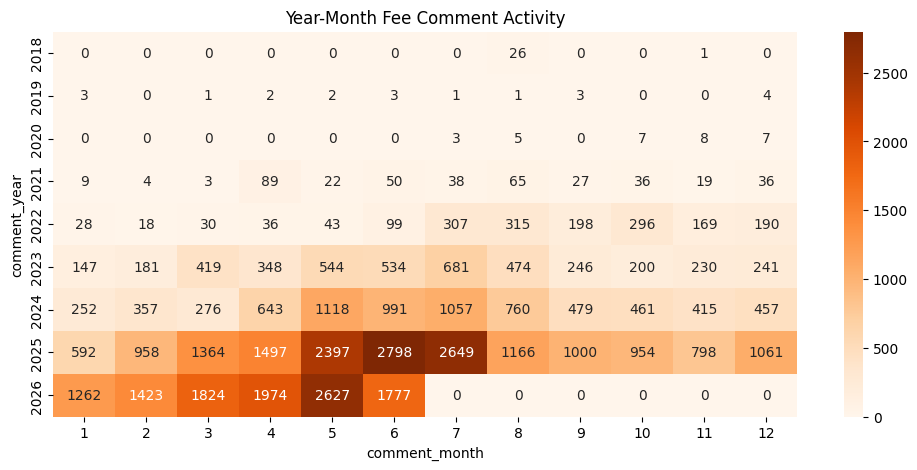

In [52]:
pivot = pd.pivot_table(
    df,
    index="comment_year",
    columns="comment_month",
    values="comment_id",
    aggfunc="count",
    fill_value=0
)

plt.figure(figsize=(12,5))

sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Year-Month Fee Comment Activity")

plt.savefig("figures/24_year_month_fee_comment_activity.png", dpi=150, bbox_inches="tight")
plt.show()

## Video-Level Analysis (india_universities_fees_videos.csv)

In [53]:
video_df = pd.read_csv("india_universities_fees_videos.csv")

video_df.head()

,university_name,category,keyword,video_id,video_title,channel_name,published_at
0,IIT Delhi,fees,fees review,kW6JmXy7evc,IIT Delhi FEES Structure (4 Year - UG/B.Tech) ...,"Mechenzi - Placements, Colleges & Career",2025-06-24T09:30:33Z
1,IIT Delhi,fees,fees review,n9URGnN1ZvA,IIT Delhi M.Tech Fees 2025 | Total Cost of Doi...,Sonu Yadav [ IIT-Delhi ],2025-03-19T09:15:03Z
2,IIT Delhi,fees,fees review,rFS4Zei2rX0,How much is IIT Fees🤔🤔#jee #jee2025 #iit #iitj...,Vedantu JEE Made Ejee,2024-10-23T03:30:29Z
3,IIT Delhi,fees,fees review,KorbSUkxgvI,💥 IIT Delhi JEE Advanced 2025 | B.Tech Fees &a...,Careers360,2025-05-16T13:26:55Z
4,IIT Delhi,fees,fees review,GqSy_t0590o,MTech Through GATE From IIT DELHI | College Fe...,GATE Wallah,2023-12-08T10:39:08Z


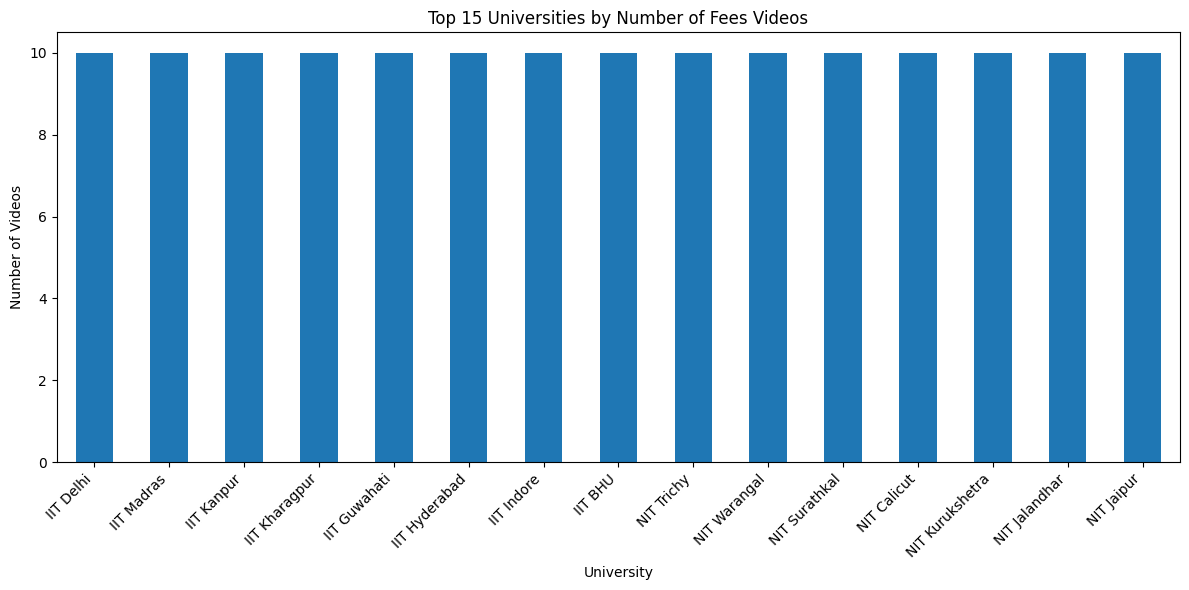

In [54]:
top_videos = video_df["university_name"].value_counts().head(15)

plt.figure(figsize=(12,6))

top_videos.plot(kind="bar")

plt.title("Top 15 Universities by Number of Fees Videos")
plt.xlabel("University")
plt.ylabel("Number of Videos")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/25_top_15_universities_by_number_of_fees_videos.png", dpi=150, bbox_inches="tight")
plt.show()

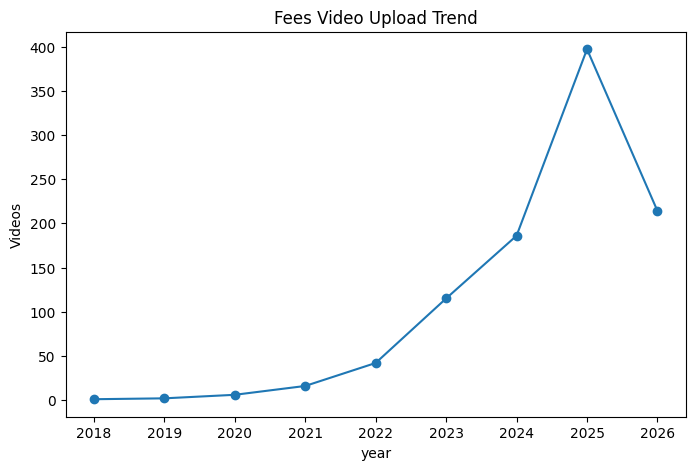

In [55]:
video_df["published_at"] = pd.to_datetime(video_df["published_at"])
video_df["year"] = video_df["published_at"].dt.year

video_df.groupby("year").size().plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Fees Video Upload Trend")
plt.ylabel("Videos")

plt.savefig("figures/26_fees_video_upload_trend.png", dpi=150, bbox_inches="tight")
plt.show()

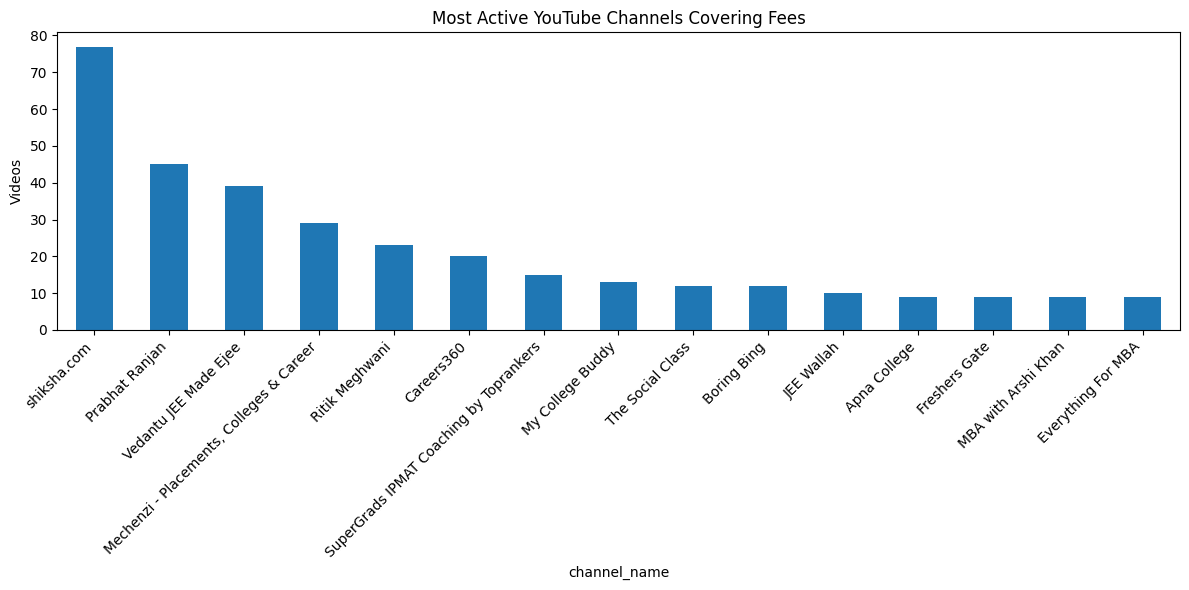

In [56]:
top_channel = video_df["channel_name"].value_counts().head(15)

top_channel.plot(kind="bar", figsize=(12,6))

plt.title("Most Active YouTube Channels Covering Fees")
plt.ylabel("Videos")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/27_most_active_youtube_channels_covering_fees.png", dpi=150, bbox_inches="tight")
plt.show()

In [57]:
# Cross-check: which universities have LOTS of comments but FEW videos?
# -> Indicates high organic demand for fee information relative to available content.

comments_per_uni = df["university_name"].value_counts()
videos_per_uni = video_df["university_name"].value_counts()

demand_gap = pd.DataFrame({
    "comments": comments_per_uni,
    "videos": videos_per_uni
}).fillna(0)

demand_gap["comments_per_video"] = (
    demand_gap["comments"] / demand_gap["videos"].replace(0, 1)
)

demand_gap.sort_values("comments_per_video", ascending=False).head(15)

,comments,videos,comments_per_video
university_name,,,
Parul University,1127.0,10,112.700000
Anna University,943.0,10,94.300000
Punjab University,932.0,10,93.200000
Delhi University,929.0,10,92.900000
Banaras Hindu University,767.0,9,85.222222
BITS Pilani,825.0,10,82.500000
Jadavpur University,695.0,9,77.222222
Symbiosis International University,751.0,10,75.100000
IIM Bangalore,669.0,9,74.333333


### Interpretation

Universities with a high **comments-per-video** ratio are ones where a handful of videos are absorbing a disproportionate amount of audience curiosity about fees — strong candidates for more dedicated fee-breakdown content.

## Overall Findings

1. **Volume & length**: Fee comments are mostly short reactions; longer comments cluster around affordability debates and detailed fee breakdowns.
2. **Dominant vocabulary**: TF, TF-IDF, and the word cloud consistently surface *lakh, hostel, scholarship, expensive, worth* as the core vocabulary of fee discussions.
3. **Fee-amount extraction** (new): a meaningful subset of comments quote specific figures, giving a crowd-sourced check against official fee data and a way to flag suspiciously off numbers.
4. **Concern categorization** (new): Affordability complaints dominate and skew negative; Scholarship/Loan questions are the most 'actionable' since they're genuine information requests.
5. **Engagement**: Comments that debate value-for-money (fee vs. placement package) earn the most likes/replies — this is the most emotionally engaging fee sub-topic.
6. **Trend**: Fee discussions spike during the admission season, aligning with decision-making windows.
7. **Demand gap**: Some universities receive heavy comment volume on very few fee videos, highlighting an under-served content opportunity.